# Training

Gefundene Emotionen: ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


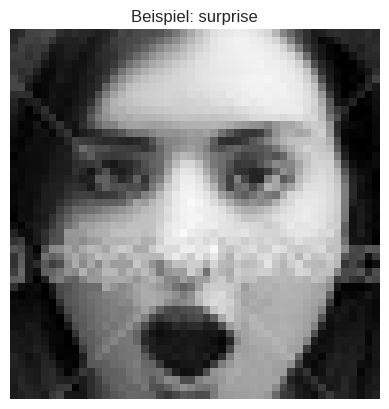

In [32]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from pathlib import Path
import pickle
# Pfade definieren
base_dir = Path('/kaggle/input/datasets/msambare/fer2013/')
train_dir = base_dir / 'train'
test_dir = base_dir / 'test'

# Kategorien anzeigen
emotions = os.listdir(train_dir)
print("Gefundene Emotionen:", emotions)

# Beispielbild anzeigen
sample_emotion = emotions[0]
sample_img_path = train_dir / sample_emotion / os.listdir(train_dir / sample_emotion)[0]
img = load_img(sample_img_path)

plt.imshow(img)
plt.title(f"Beispiel: {sample_emotion}")
plt.axis('off')
plt.show()

## Baseline mit einfachem CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisierung (1./255) + Augmentierung für das Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # 20% für die Validierung abspalten
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Datengeneratoren erstellen (FER-2013 Bilder sind 48x48 Pixel, Graustufen)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)
# Modernes Keras 3 Syntax mit explizitem Input-Layer
model = Sequential([
    Input(shape=(48, 48, 1)), # Eingabegröße hier sauber definieren
    
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training starten
baseline_cnn_history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Modell lokal im Kaggle-Output speichern
model.save('baseline_cnn_model.keras')
with open("history_baseline_cnn.pkl", "wb") as f:
   pickle.dump(baseline_cnn_history.history, f)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Epoch 1/10
 20/359 ━━━━━━━━━━━━━━━━━━━━ 3:27 611ms/step - accuracy: 0.2169 - loss: 1.8875

In [ ]:
model.save('baseline_cnn_model.keras')

## ResNet50 unaugmented

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

resnet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Basis-Schichten einfrieren (Weights werden nicht aktualisiert)
base_model.trainable = True

# 3. Eigene Klassifikations-Schichten aufbauen
resnet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),
        
    Resizing(224, 224), # ResNet50 erwartet 224x224
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

history_resnet = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
resnet_model.save('resnet.keras')
with open("history_resnet.pkl", "wb") as f:
   pickle.dump(history_resnet.history, f)

## MobileNetV2 unaugmented

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

mobilenet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

# 3. Eigene Klassifikations-Schichten aufbauen
mobilenet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),
        
    Resizing(224, 224),
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
mobilenet_model.save('mobilenet.keras')
with open("history_mobilenet.pkl", "wb") as f:
   pickle.dump(history_mobilenet.history, f)

## resnet augmented

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

resnet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Basis-Schichten einfrieren (Weights werden nicht aktualisiert)
base_model.trainable = True

# 3. Eigene Klassifikations-Schichten aufbauen
resnet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),

    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(factor=15/360),             # rotation_range=15 Grad
    RandomZoom(height_factor=(-0.15, 0.15)),    # zoom_range=0.15
    RandomTranslation(                          # width & height shift range=0.1
        height_factor=0.1, 
        width_factor=0.1
    ),
    
    Resizing(224, 224), # ResNet50 erwartet 224x224
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

history_resnet_augmented = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
resnet_model.save('resnet_augmented.keras')
with open("history_resnet_augmented.pkl", "wb") as f:
   pickle.dump(history_resnet_augmented.history, f)

## mobilenet augmented

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

mobilenet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

# 3. Eigene Klassifikations-Schichten aufbauen
mobilenet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),

    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(factor=15/360),             # rotation_range=15 Grad
    RandomZoom(height_factor=(-0.15, 0.15)),    # zoom_range=0.15
    RandomTranslation(                          # width & height shift range=0.1
        height_factor=0.1, 
        width_factor=0.1
    ),
    
    Resizing(224, 224),
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

history_mobilenet_augmented = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
mobilenet_model.save('mobilenet_augmented.keras')
with open("history_mobilenet_augmented.pkl", "wb") as f:
   pickle.dump(history_mobilenet_augmented.history, f)

## resnet augmented mit naivem Freezing

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

resnet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Die ersten N Schichten eingefroren lassen, nur die obersten ~30 Schichten trainieren
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. Eigene Klassifikations-Schichten aufbauen
resnet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),

    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(factor=15/360),             # rotation_range=15 Grad
    RandomZoom(height_factor=(-0.15, 0.15)),    # zoom_range=0.15
    RandomTranslation(                          # width & height shift range=0.1
        height_factor=0.1, 
        width_factor=0.1
    ),
    
    Resizing(224, 224), # ResNet50 erwartet 224x224
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

history_resnet_augmented_freezed = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
resnet_model.save('resnet_augmented_freezed.keras')
with open("history_resnet_augmented_freezed.pkl", "wb") as f:
   pickle.dump(history_resnet_augmented_freezed.history, f)

## ResNet50 augmented + classweights

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

resnet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 1. Base Model laden (ohne Top-Klassifikationsschicht)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

# 3. Eigene Klassifikations-Schichten aufbauen
resnet_model = Sequential([
    Input(shape=(48, 48, 3)),
    Rescaling(1./255),

    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(factor=15/360),             # rotation_range=15 Grad
    RandomZoom(height_factor=(-0.15, 0.15)),    # zoom_range=0.15
    RandomTranslation(                          # width & height shift range=0.1
        height_factor=0.1, 
        width_factor=0.1
    ),
    
    Resizing(224, 224), # ResNet50 erwartet 224x224
    
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# 4. Modell kompilieren
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

# 5. Class-Weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Klassen-Gewichte berechnen
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

history_resnet_augmented_classweights = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight_dict
)
resnet_model.save('resnet_augmented_classweights.keras')
with open("history_resnet_augmented_classweights.pkl", "wb") as f:
   pickle.dump(history_resnet_augmented_classweights.history, f)

## Zweistufige Trainingspipeline mit selectivem Freezing

In [ ]:
import tensorflow as tf
import pickle

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ============================================================
# 1. Daten
# ============================================================

resnet_train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


# ============================================================
# 2. Funktion zum Erstellen des Modells
# ============================================================

def create_resnet_model():

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    model = Sequential([
        Input(shape=(48, 48, 3)),
        Rescaling(1.0 / 255),
        RandomFlip("horizontal"),
        RandomRotation(
            factor=15 / 360
        ),
        RandomZoom(
            height_factor=(-0.15, 0.15)
        ),
        RandomTranslation(
            height_factor=0.1,
            width_factor=0.1
        ),
        Resizing(224, 224),
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),

        Dropout(0.5),

        Dense(len(emotions), activation="softmax")
    ])

    return model, base_model


# 3. Einfrieren / Freigeben der ResNet-Stages
def set_trainable_stages(base_model, stages):

    # Zunächst ALLES einfrieren
    base_model.trainable = False

    # Gewünschte Stages freigeben
    for layer in base_model.layers:
        for stage in stages:
            if layer.name.startswith(stage):
                layer.trainable = True


# 4. komplette zweistufige Variante
def train_two_stage_model(
    stages,
    model_name,
    phase1_epochs=10,
    phase2_epochs=10
):

    print("\n")
    print("=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)

    model, base_model = create_resnet_model()


    # PHASE 1 - ResNet komplett einfrieren, nur der neue classifier wird trainiert
    print("\n")
    print("=" * 70)
    print("PHASE 1: CLASSIFIER TRAINING")
    print("=" * 70)

    base_model.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("\nTrainierbare Layer in Phase 1:")

    for layer in model.layers:
        if layer.trainable:
            print(
                layer.name,
                type(layer).__name__
            )

    history_phase1 = model.fit(
        train_generator,
        epochs=phase1_epochs,
        validation_data=val_generator
    )

    # PHASE 2 - Gewünschte ResNet-Stages freigeben
    print("\n")
    print("=" * 70)
    print("PHASE 2: FINE-TUNING")
    print("=" * 70)

    set_trainable_stages(
        base_model,
        stages
    )

    print("\nFreigegebene ResNet-Stages:")
    print(stages)

    print("\nTrainierbare ResNet-Layer:")

    for layer in base_model.layers:
        if layer.trainable:
            print(
                layer.name,
                type(layer).__name__
            )


    # Nach Änderung von trainable erneut kompilieren
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-5
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_phase2 = model.fit(
        train_generator,
        epochs=phase2_epochs,
        validation_data=val_generator
    )

    # Ergebnisse zusammenführen
    history = {}

    for key in history_phase1.history.keys():
        history[key] = (history_phase1.history[key] + history_phase2.history[key])

    # Modell speichern
    model.save(f"{model_name}.keras")

    # History speichern
    with open(f"history_{model_name}.pkl","wb") as f:
        pickle.dump(history,f)

    print("\n")
    print("=" * 70)
    print(f"{model_name} FERTIG")
    print("=" * 70)

    print(
        f"Beste Validation Accuracy: "
        f"{max(history['val_accuracy']):.4f}"
    )

    return model, history

model_conv5, history_conv5 = train_two_stage_model(
    stages=["conv5_"],
    model_name="resnet_conv5_two_stage",
    phase1_epochs=10,
    phase2_epochs=10
)

model_conv4_5, history_conv4_5 = train_two_stage_model(
    stages=["conv4_", "conv5_"],
    model_name="resnet_conv4_5_two_stage",
    phase1_epochs=10,
    phase2_epochs=10
)

model_conv3_5, history_conv3_5 = train_two_stage_model(
    stages=["conv3_", "conv4_", "conv5_"],
    model_name="resnet_conv3_5_two_stage",
    phase1_epochs=10,
    phase2_epochs=10
)

## Loss und Accuracy Plots

## Alle Modelle in einem Plot

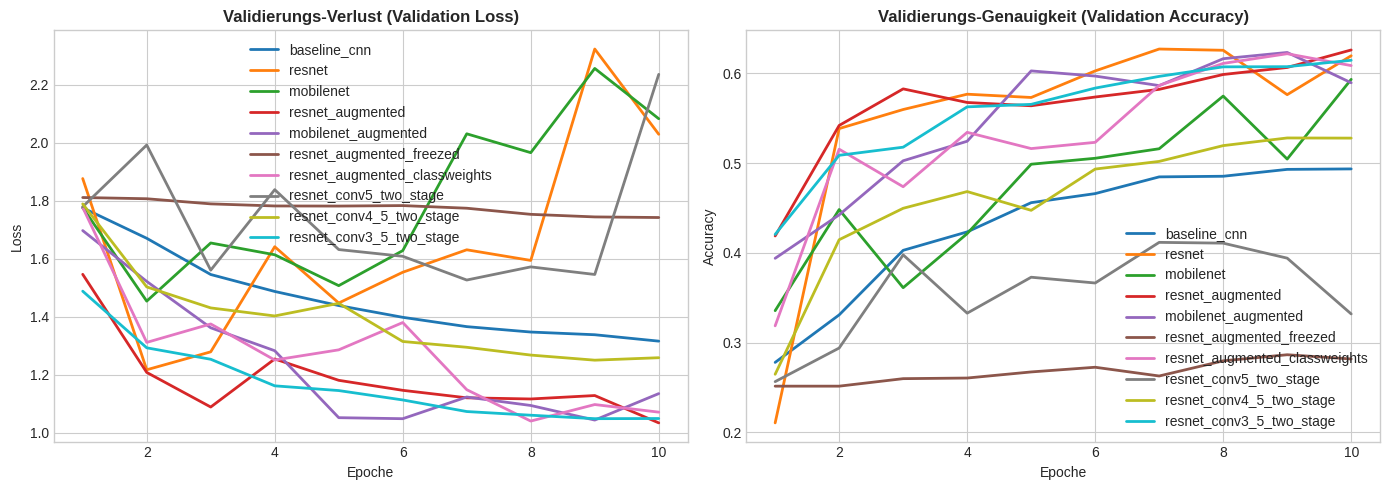

max-accuracies:
baseline_cnn: 0.493
resnet: 0.627
mobilenet: 0.593
resnet_augmented: 0.626
mobilenet_augmented: 0.623
resnet_augmented_freezed: 0.286
resnet_augmented_classweights: 0.622
resnet_conv5_two_stage: 0.412
resnet_conv4_5_two_stage: 0.528
resnet_conv3_5_two_stage: 0.615

last-epoch-accuracies:
baseline_cnn: 0.493
resnet: 0.620
mobilenet: 0.593
resnet_augmented: 0.626
mobilenet_augmented: 0.589
resnet_augmented_freezed: 0.282
resnet_augmented_classweights: 0.609
resnet_conv5_two_stage: 0.332
resnet_conv4_5_two_stage: 0.528
resnet_conv3_5_two_stage: 0.615


In [2]:
import pickle
history_files = [
    "/kaggle/working/history_baseline_cnn.pkl",
    "/kaggle/working/history_resnet.pkl",
    "/kaggle/working/history_mobilenet.pkl",
    "/kaggle/working/history_resnet_augmented.pkl",
    "/kaggle/working/history_mobilenet_augmented.pkl",
    "/kaggle/working/history_resnet_augmented_freezed.pkl",
    "/kaggle/working/history_resnet_augmented_classweights.pkl",
    "/kaggle/working/history_resnet_conv5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv4_5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv3_5_two_stage.pkl",
]

import re
histories = {}
for filename in history_files:
    with open(filename, "rb") as f:
        histories[re.search(r"history_(.*?)\.pkl", filename).group(1)] = pickle.load(f)

# die mehrstufige pipeline wurde 2x10 Epochen trainiert, zur Visualisierung betrachte ich nur die zweite Stufe
runs_20_epochs = ["resnet_conv5_two_stage", "resnet_conv4_5_two_stage", "resnet_conv3_5_two_stage"]
for run_20_epochs in runs_20_epochs:
    histories[run_20_epochs]['val_loss'] = histories[run_20_epochs]['val_loss'][10:]
    histories[run_20_epochs]['val_accuracy'] = histories[run_20_epochs]['val_accuracy'][10:]

# Trainings-Plots
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Validierungs-Loss
for name, data in histories.items():
    epochs = range(1, len(data['val_loss']) + 1) # Erzeugt x-Werte von 1 bis N
    axes[0].plot(epochs, data['val_loss'], label=name, linewidth=2)

axes[0].set_title('Validierungs-Verlust (Validation Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Plot Validierungs-Genauigkeit
for name, data in histories.items():
    epochs = range(1, len(data['val_accuracy']) + 1) # Erzeugt x-Werte von 1 bis N
    axes[1].plot(epochs, data['val_accuracy'], label=name, linewidth=2)

axes[1].set_title('Validierungs-Genauigkeit (Validation Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Accuracy')
axes[1].legend()


plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

print('max-accuracies:')
for model_name, model_history in histories.items():
    print(f"{model_name}: {max(model_history['val_accuracy']):.3f}")
print("\nlast-epoch-accuracies:")
for model_name, model_history in histories.items():
    print(f"{model_name}: {model_history['val_accuracy'][-1]:.3f}")

## Schlüsselmodelle in einem Plot

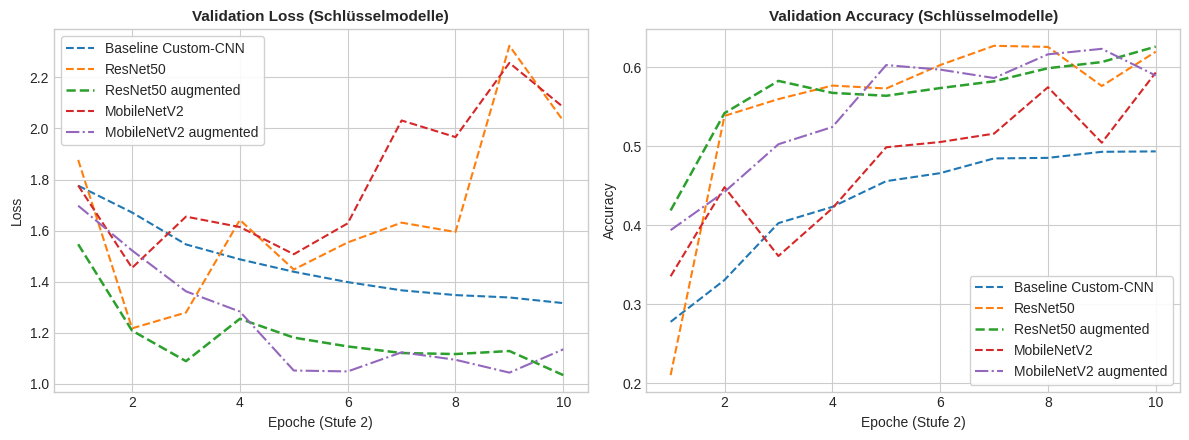

In [10]:
import pickle
import re
import matplotlib.pyplot as plt

# 1. Dateipfade & Laden
history_files = [
    "/kaggle/working/history_baseline_cnn.pkl",
    "/kaggle/working/history_resnet.pkl",
    "/kaggle/working/history_mobilenet.pkl",
    "/kaggle/working/history_resnet_augmented.pkl",
    "/kaggle/working/history_mobilenet_augmented.pkl",
    "/kaggle/working/history_resnet_augmented_freezed.pkl",
    "/kaggle/working/history_resnet_augmented_classweights.pkl",
    "/kaggle/working/history_resnet_conv5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv4_5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv3_5_two_stage.pkl",
]

histories = {}
for filename in history_files:
    match = re.search(r"history_(.*?)\.pkl", filename)
    if match:
        key = match.group(1)
        with open(filename, "rb") as f:
            histories[key] = pickle.load(f)

# 2. Ausgewählte Schlüsselmodelle definieren
focus_models = {
    'baseline_cnn': {'label': 'Baseline Custom-CNN', 'ls': '--', 'lw': 1.5},
    'resnet': {'label': 'ResNet50', 'ls': '--', 'lw': 1.5},
    'resnet_augmented': {'label': 'ResNet50 augmented', 'ls': '--', 'lw': 1.8},
    'mobilenet': {'label': 'MobileNetV2', 'ls': '--', 'lw': 1.5},
    'mobilenet_augmented': {'label': 'MobileNetV2 augmented', 'ls': '-.', 'lw': 1.5}
}

# 3. Plotting für Hauptteil
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for key, config in focus_models.items():
    if key in histories:
        data = histories[key]
        epochs = range(1, len(data['val_loss']) + 1)
        
        axes[0].plot(epochs, data['val_loss'], label=config['label'], 
                     linestyle=config['ls'], linewidth=config['lw'])
        axes[1].plot(epochs, data['val_accuracy'], label=config['label'], 
                     linestyle=config['ls'], linewidth=config['lw'])

# Subplot 1: Validation Loss
axes[0].set_title('Validation Loss (Schlüsselmodelle)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoche (Stufe 2)')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=True, facecolor='white', framealpha=0.9)

# Subplot 2: Validation Accuracy
axes[1].set_title('Validation Accuracy (Schlüsselmodelle)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoche (Stufe 2)')
axes[1].set_ylabel('Accuracy')
axes[1].legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('learning_curves_focused.png', dpi=300, bbox_inches='tight')
plt.show()

## Alle Modelle

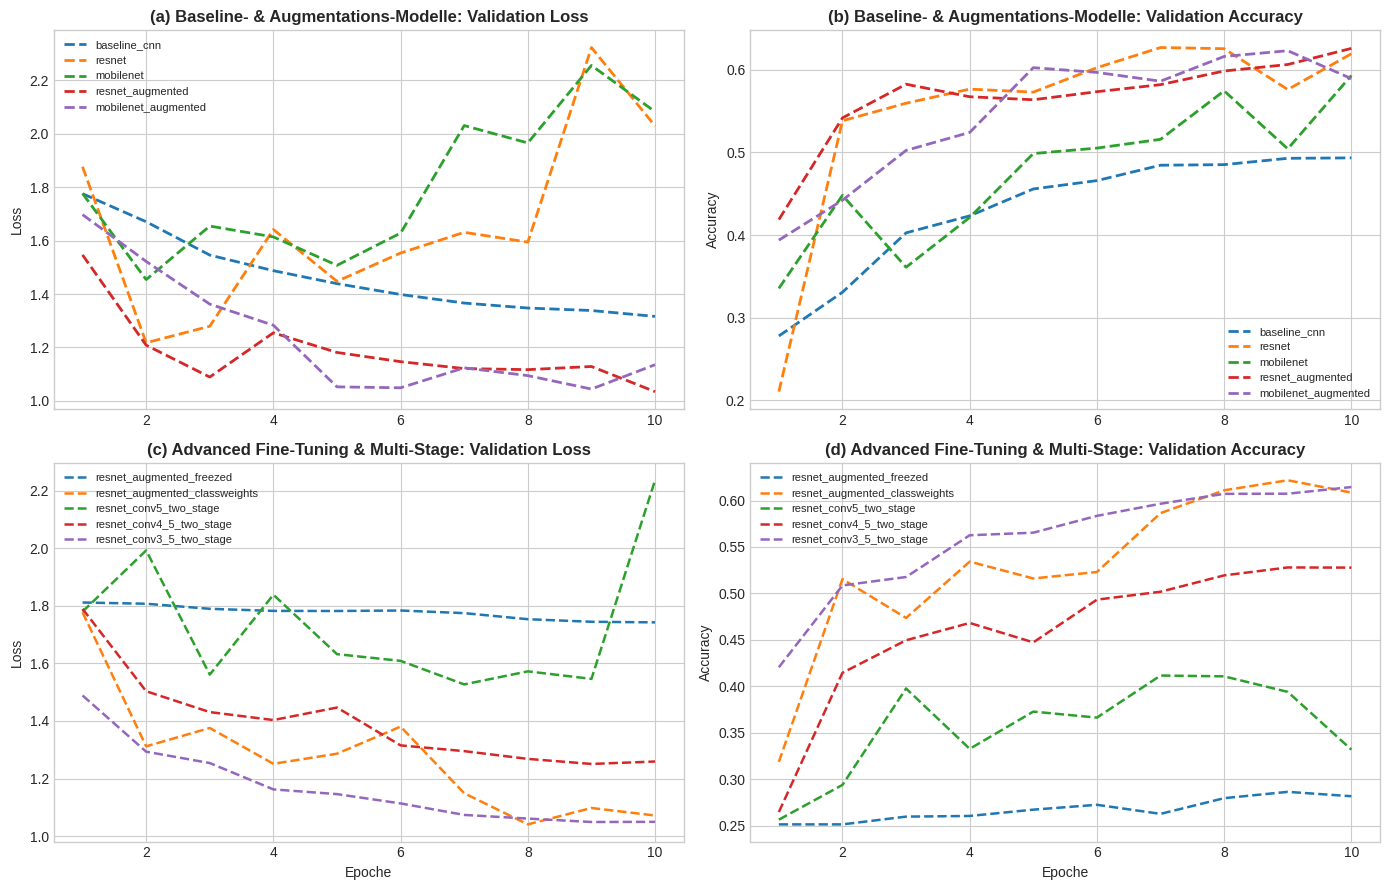

In [8]:
import pickle
import re
import matplotlib.pyplot as plt

# 1. Pfade & Laden 
history_files = [
    "/kaggle/working/history_baseline_cnn.pkl",
    "/kaggle/working/history_resnet.pkl",
    "/kaggle/working/history_mobilenet.pkl",
    "/kaggle/working/history_resnet_augmented.pkl",
    "/kaggle/working/history_mobilenet_augmented.pkl",
    "/kaggle/working/history_resnet_augmented_freezed.pkl",
    "/kaggle/working/history_resnet_augmented_classweights.pkl",
    "/kaggle/working/history_resnet_conv5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv4_5_two_stage.pkl",
    "/kaggle/working/history_resnet_conv3_5_two_stage.pkl",
]

histories = {}
for filename in set(history_files):  # set() entfernt eventuelle Duplikate
    match = re.search(r"history_(.*?)\.pkl", filename)
    if match:
        key = match.group(1)
        with open(filename, "rb") as f:
            histories[key] = pickle.load(f)

# Aufbereitung der 2-Stage-Läufe
runs_20_epochs = ["resnet_conv5_two_stage", "resnet_conv4_5_two_stage", "resnet_conv3_5_two_stage"]
for run in runs_20_epochs:
    if run in histories:
        histories[run]['val_loss'] = histories[run]['val_loss'][10:]
        histories[run]['val_accuracy'] = histories[run]['val_accuracy'][10:]

# 2. Gruppierung für 2 Subfigures im Anhang
group_1 = ['baseline_cnn', 'resnet', 'mobilenet', 'resnet_augmented', 'mobilenet_augmented']
group_2 = ['resnet_augmented_freezed', 'resnet_augmented_classweights', 
           'resnet_conv5_two_stage', 'resnet_conv4_5_two_stage', 'resnet_conv3_5_two_stage']

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Gruppe 1 Plotten (Baselines & In-Model Augmentation)
for name in group_1:
    if name in histories:
        epochs = range(1, len(histories[name]['val_loss']) + 1)
        axes[0, 0].plot(epochs, histories[name]['val_loss'], label=name, linestyle='--', linewidth=2)
        axes[0, 1].plot(epochs, histories[name]['val_accuracy'], linestyle='--', label=name, linewidth=2)

axes[0, 0].set_title('(a) Baseline- & Augmentations-Modelle: Validation Loss', fontweight='bold')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8, loc='upper left')

axes[0, 1].set_title('(b) Baseline- & Augmentations-Modelle: Validation Accuracy', fontweight='bold')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=8, loc='lower right')

# Gruppe 2 Plotten (Freezing, Class Weights & Two-Stage Fine-Tuning)
for name in group_2:
    if name in histories:
        epochs = range(1, len(histories[name]['val_loss']) + 1)
        lw = 1.8
        axes[1, 0].plot(epochs, histories[name]['val_loss'], linestyle='--', label=name, linewidth=lw)
        axes[1, 1].plot(epochs, histories[name]['val_accuracy'], linestyle='--', label=name, linewidth=lw)

axes[1, 0].set_title('(c) Advanced Fine-Tuning & Multi-Stage: Validation Loss', fontweight='bold')
axes[1, 0].set_xlabel('Epoche')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(fontsize=8, loc='upper left')

axes[1, 1].set_title('(d) Advanced Fine-Tuning & Multi-Stage: Validation Accuracy', fontweight='bold')
axes[1, 1].set_xlabel('Epoche')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('learning_curves_appendix.png', dpi=300, bbox_inches='tight')
plt.show()

# Evaluation ResNet50 augmented

Found 7178 files belonging to 7 classes.

Lade Champion-Modell...
Berechne Vorhersagen für das Test-Set...
225/225 ━━━━━━━━━━━━━━━━━━━━ 34s 141ms/step

             CLASSIFICATION REPORT (TEST-SET)
              precision    recall  f1-score   support

    surprise     0.5955    0.5303    0.5610       958
        fear     0.8387    0.2342    0.3662       111
       angry     0.6293    0.2520    0.3598      1024
     neutral     0.8292    0.8732    0.8506      1774
         sad     0.4553    0.7599    0.5694      1233
     disgust     0.5020    0.5044    0.5032      1247
       happy     0.8099    0.6871    0.7435       831

    accuracy                         0.6239      7178
   macro avg     0.6657    0.5487    0.5648      7178
weighted avg     0.6463    0.6239    0.6134      7178



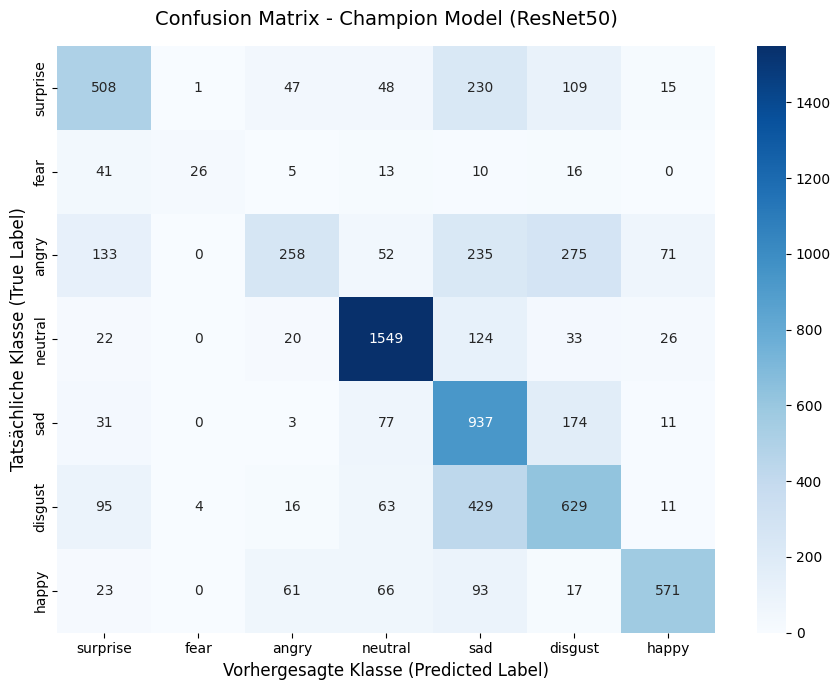

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from pathlib import Path
import os
import pickle

# 1. Setup
# model_path = "/kaggle/input/notebooks/thomasanschtz/cv-project/resnet_augmented.keras"
model_path = "/kaggle/working/resnet_augmented.keras"

test_dir = Path('/kaggle/input/datasets/msambare/fer2013/test')
img_size = (48, 48)
batch_size = 32
emotions = os.listdir(test_dir)

# 2. Testdaten laden
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    label_mode="categorical",
)

# 3. MODELL LADEN & INFERENZ AUF TESTDATEN
print("\nLade Champion-Modell...")
model = tf.keras.models.load_model(model_path)

print("Berechne Vorhersagen für das Test-Set...")
predictions = model.predict(test_ds)

# Konvertiere Softmax-Wahrscheinlichkeiten in Klassen-Indizes (0 bis 6)
y_pred = np.argmax(predictions, axis=1)

# Extraktion der tatsächlichen Klassen aus dem Dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# 4. Metriken
print("\n" + "=" * 60)
print("             CLASSIFICATION REPORT (TEST-SET)")
print("=" * 60)
report = classification_report(
    y_true, y_pred, target_names=emotions, digits=4
)
print(report)
with open(f"classification_report.pkl","wb") as f:
    pickle.dump(report,f)

# 5. confusion-matrix
cm = confusion_matrix(y_true, y_pred)
with open(f"confusion_matrix.pkl","wb") as f:
    pickle.dump(cm,f)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotions,
    yticklabels=emotions,
    cbar=True,
)
plt.title("Confusion Matrix - Champion Model (ResNet50)", fontsize=14, pad=15)
plt.xlabel("Vorhergesagte Klasse (Predicted Label)", fontsize=12)
plt.ylabel("Tatsächliche Klasse (True Label)", fontsize=12)
plt.tight_layout()

plt.savefig("confusion_matrix_resnet.png", dpi=300)
plt.show()